In [1]:
from qiskit import __version__
print(__version__)

2.1.1


In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Pauli, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_aer.library import SaveDensityMatrix
from qiskit import transpile 
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.library import HGate, UnitaryGate, IGate
import matplotlib.pyplot as plt

In [3]:
theta = np.arctan(np.sqrt((np.sqrt(5) - 1) / 2))
amp_0 = np.cos(theta/2)
amp_1 = np.sin(theta/2)

In [4]:
# Create custom gates
H_matrix = HGate().to_matrix()
hadamard_custom = UnitaryGate(H_matrix, label='hadamard_custom')

ID_matrix = IGate().to_matrix()
encoding_err = UnitaryGate(ID_matrix, label='encoding_err')

idle_matrix = IGate().to_matrix()
idle = UnitaryGate(idle_matrix, label='idle')

ry_sub = QuantumCircuit(1, name='RY_custom')
ry_sub.ry(theta, 0)
RY_custom = ry_sub.to_gate()

In [5]:
ideal = Statevector([0.94502682+4.48585114e-15j, 0.        +0.00000000e+00j,
             0.        +0.00000000e+00j, 0.        +0.00000000e+00j,
             0.32699283+1.66142635e-15j, 0.        +0.00000000e+00j,
             0.        +0.00000000e+00j, 0.        +0.00000000e+00j],
            dims=(2, 2, 2))

# Circuit

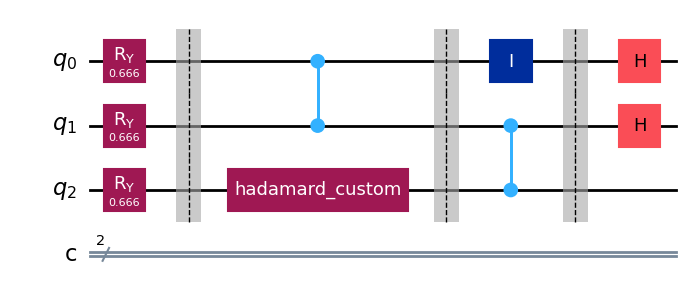

In [6]:
circuit = QuantumCircuit(3, 2)

# State prep
for i in range(3):
    circuit.ry(theta, i)
circuit.barrier()

circuit.cz(0,1)
circuit.append(hadamard_custom, [2])
circuit.barrier()

circuit.id(0)
circuit.cz(1,2)
circuit.barrier()

circuit.h(0)
circuit.h(1)

display(circuit.draw(output='mpl'))

# Infidelity to Error Rates

In [7]:
def inf_to_error(infidelity_list, num_qubits):
    error_rates_list = []
    dimension = 2**num_qubits
    for infidelity in infidelity_list:
        error_rates_list.append( infidelity * (dimension / (dimension - 1)) )
    
    return error_rates_list

In [8]:
one_qubit_gate_infidelity = [2.8e-5 * i for i in range(1,6)]
two_qubit_gate_infidelity = [8.3e-4 * i for i in range(1,6)]
idle_gate_infidelity = [1.2e-4 * i for i in range(1,6)]
spam0 = [6.7e-4 * i for i in range(1,6)] # P(1|0), measured 1 given that 0 was prepared
spam1 = [1.2e-3 * i for i in range(1,6)] # P(0|1)

In [9]:
one_qubit_gate_error_prob = inf_to_error(one_qubit_gate_infidelity, num_qubits=1)
two_qubit_gate_error_prob = inf_to_error(two_qubit_gate_infidelity, num_qubits=2)
idle_gate_error_prob = inf_to_error(idle_gate_infidelity, num_qubits=1)

# Simulations

In [22]:
all_fidelity = []
all_fidelity_unc = []
shots = 1_000_000

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['hadamard_custom'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(idle_gate_error_prob[i], 1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_gate_error_prob[i], 2), ['cz']) 
    
    readout_err = ReadoutError([[1-spam0[i], spam0[i]],  # P(0|0), P(1|0)
                            [spam1[i], 1-spam1[i]]]) # P(0|1), P(1|1)
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.save_statevector(label='state_post', pershot=True, conditional=True)

    backend = AerSimulator(noise_model=noise_model)
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_statevectors = result.data()['state_post']
    num_meas = len(res_statevectors['0x0'])
    sumfid = 0
    for shot in res_statevectors['0x0']:
        sumfid += state_fidelity(shot, ideal)
    sumfid /= num_meas
    
    all_fidelity.append(sumfid)
    all_fidelity_unc.append( 1.96 * np.sqrt( (sumfid)*(1 - sumfid) / num_meas) )

all_infidelity = [1-f for f in all_fidelity]

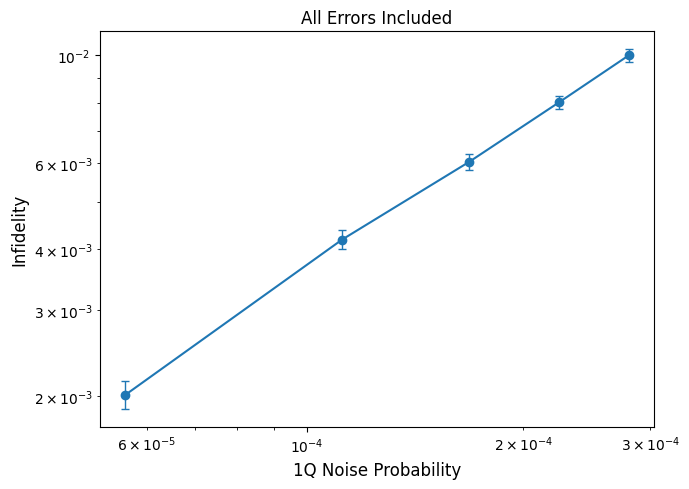

In [23]:
plt.figure(figsize=(7, 5))
plt.errorbar(
    one_qubit_gate_error_prob,
    all_infidelity,
    yerr=all_fidelity_unc,
    fmt='o-',           # circle marker and solid line
    capsize=3,          # length of the little “T” caps on each bar
    elinewidth=1,       # width of the error‐bar lines
    markeredgewidth=1
)
plt.xlabel("1Q Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.title("All Errors Included")
plt.tight_layout()
plt.show()

Input simulations

In [10]:
ry_theta = np.array([[np.cos(theta/2), -np.sin(theta/2)], [np.sin(theta/2), np.cos(theta/2)]])

one_q_zero_dm = np.matmul([[1], [0]], [[1,0]])
ideal_input = ry_theta @ one_q_zero_dm @ ry_theta.conj().T

ideal_input /= np.trace(ideal_input)
ideal_input = DensityMatrix(ideal_input)

In [11]:
input_circuit = QuantumCircuit(1)
input_circuit.ry(theta,0)

In [ ]:
all_input_fidelity = []
shots = 1

for i in range(len(one_qubit_gate_error_prob)):
    nm = NoiseModel()
    
    nm.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ["ry"])
    
    input_copy = input_circuit.copy()
    #input_copy.save_density_matrix(label='density_matrix_post', pershot=True, conditional=True)
    input_copy.append(SaveDensityMatrix(num_qubits=1, label='density_matrix_post', conditional=True, pershot=True), input_copy.qubits)
    
    backend = AerSimulator(noise_model=nm, method='density_matrix')
    job = backend.run(input_copy, shots=shots)
    result = job.result()

    res_density_matrix = result.data()['density_matrix_post']
    
    all_input_fidelity.append(state_fidelity(ideal_input, res_density_matrix[''][0]))

all_input_infidelity = [1-f for f in all_input_fidelity]

# What is the success probability

In [ ]:
all_fidelity = []
all_fidelity_unc = []
shots = 1_000_000
success_prob_list = []
prob_meas_00_list = []

for i in range(len(one_qubit_gate_error_prob)):
    num_success = 0
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['hadamard_custom'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(idle_gate_error_prob[i], 1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_gate_error_prob[i], 2), ['cz']) 
    
    readout_err = ReadoutError([[1-spam0[i], spam0[i]],  # P(0|0), P(1|0)
                            [spam1[i], 1-spam1[i]]]) # P(0|1), P(1|1)
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.save_statevector(label='state_post', pershot=True, conditional=True)

    backend = AerSimulator(noise_model=noise_model)
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_statevectors = result.data()['state_post']
    num_meas = len(res_statevectors['0x0'])
    for shot in res_statevectors['0x0']:
        fid = state_fidelity(shot, ideal)
        if (round(fid, 2) == 1.00):
            num_success += 1 
    
    success_prob_list.append(num_success/num_meas)
    prob_meas_00_list.append(num_meas/shots)

In [281]:
print(success_prob_list)
print(prob_meas_00_list)

[0.9972672887072552, 0.9944355960565311, 0.9917347383753602, 0.9888097522738637, 0.9859037863216183]
[0.446809, 0.446409, 0.444874, 0.443958, 0.445155]


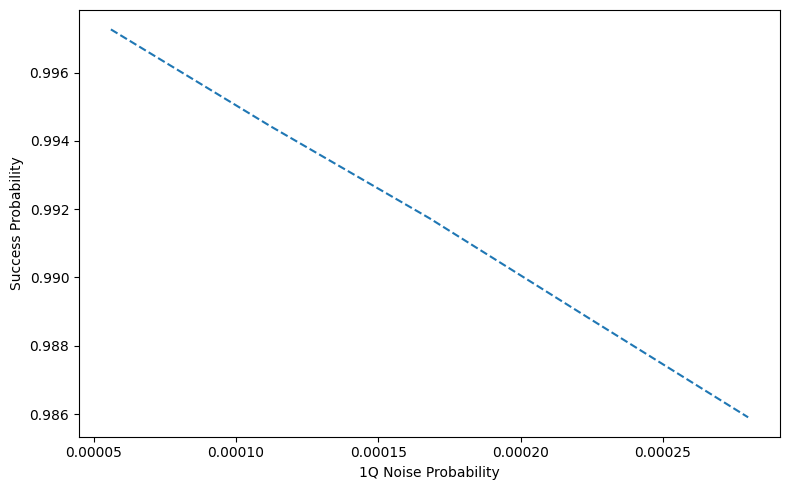

In [284]:
plt.figure(figsize=(8,5))
plt.plot(one_qubit_gate_error_prob, success_prob_list, linestyle='--')

plt.xlabel('1Q Noise Probability')
plt.ylabel('Success Probability')
plt.tight_layout()
plt.show()

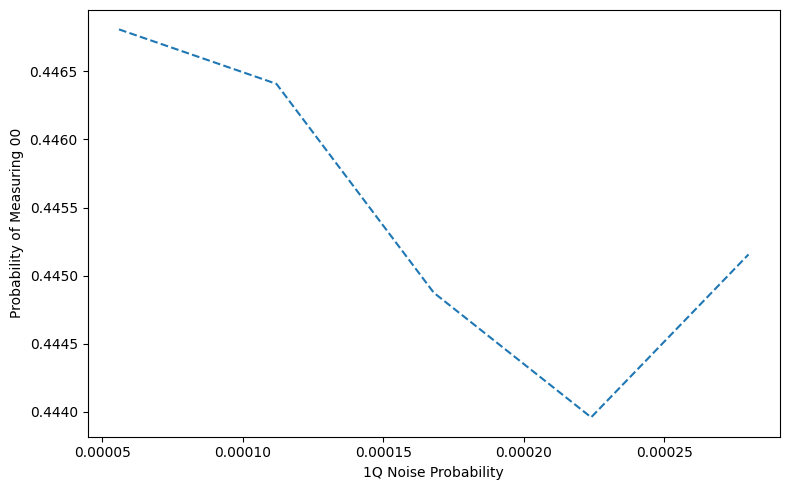

In [285]:
plt.figure(figsize=(8,5))
plt.plot(one_qubit_gate_error_prob, prob_meas_00_list, linestyle='--')

plt.xlabel('1Q Noise Probability')
plt.ylabel('Probability of Measuring 00')
plt.tight_layout()
plt.show()

# Circuit Component Analysis

In [24]:
identity = [[1,0], [0,1]]
ry_theta = [[np.cos(theta/2), -np.sin(theta/2)], [np.sin(theta/2), np.cos(theta/2)]]

one_q_zero_dm = np.matmul([[1], [0]], [[1,0]])
ideal = np.kron(one_q_zero_dm, np.kron(one_q_zero_dm, one_q_zero_dm))

ry_i_i = np.kron(ry_theta, np.kron(identity, identity))
ideal = ry_i_i @ ideal @ ry_i_i.conj().T 

ideal /= np.trace(ideal)
ideal = DensityMatrix(ideal)

In [25]:
# Entire distillation circuit is ideal, plot the input and output infidelities
fidelity_results = []
shots = 50

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ["ry"])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    #meas_circuit_noise.save_density_matrix(label='dm_post', pershot=True, conditional=True)
    meas_circuit_noise.append(SaveDensityMatrix(num_qubits=3, label='dm_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_statevectors = result.data()['dm_post']
    fidelity_results.append(state_fidelity(ideal, res_statevectors['0x0'][0]))
    
plot1_y = [1 - f for f in fidelity_results]

In [26]:
# Disregard measurement errors, plot the input and output infidelities
fidelity_results = []
shots = 50

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['hadamard_custom'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(idle_gate_error_prob[i], 1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_gate_error_prob[i], 2), ['cz']) 
    
    #readout_err = ReadoutError([[1-spam0[i], spam0[i]],  # P(0|0), P(1|0)
                            #[spam1[i], 1-spam1[i]]]) # P(0|1), P(1|1)
    #noise_model.add_readout_error(readout_err, [0])
    #noise_model.add_readout_error(readout_err, [1])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.append(SaveDensityMatrix(num_qubits=3, label='dm_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_statevectors = result.data()['dm_post']
    fidelity_results.append(state_fidelity(ideal, res_statevectors['0x0'][0]))
    
plot2_y = [1 - f for f in fidelity_results]

In [27]:
# Disregard idling errors, plot the input and output infidelities
fidelity_results = []
shots = 50

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['hadamard_custom'])
    #noise_model.add_all_qubit_quantum_error(depolarizing_error(idle_gate_error_prob[i], 1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_gate_error_prob[i], 2), ['cz']) 
    
    readout_err = ReadoutError([[1-spam0[i], spam0[i]],  # P(0|0), P(1|0)
                            [spam1[i], 1-spam1[i]]]) # P(0|1), P(1|1)
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.append(SaveDensityMatrix(num_qubits=3, label='dm_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_statevectors = result.data()['dm_post']
    fidelity_results.append(state_fidelity(ideal, res_statevectors['0x0'][0]))
    
plot3_y = [1 - f for f in fidelity_results]

In [29]:
# Disregard cz errors, plot the input and output infidelities
fidelity_results = []
shots = 50

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['hadamard_custom'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(idle_gate_error_prob[i], 1), ['id'])
    #noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_gate_error_prob[i], 2), ['cz']) 
    
    readout_err = ReadoutError([[1-spam0[i], spam0[i]],  # P(0|0), P(1|0)
                            [spam1[i], 1-spam1[i]]]) # P(0|1), P(1|1)
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.append(SaveDensityMatrix(num_qubits=3, label='dm_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_statevectors = result.data()['dm_post']
    fidelity_results.append(state_fidelity(ideal, res_statevectors['0x0'][0]))
    
plot4_y = [1 - f for f in fidelity_results]

In [30]:
# Disregard hadamard errors, plot the input and output infidelities
fidelity_results = []
shots = 50

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    #noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['hadamard_custom'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(idle_gate_error_prob[i], 1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_gate_error_prob[i], 2), ['cz']) 
    
    readout_err = ReadoutError([[1-spam0[i], spam0[i]],  # P(0|0), P(1|0)
                            [spam1[i], 1-spam1[i]]]) # P(0|1), P(1|1)
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.append(SaveDensityMatrix(num_qubits=3, label='dm_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_statevectors = result.data()['dm_post']
    fidelity_results.append(state_fidelity(ideal, res_statevectors['0x0'][0]))
    
plot5_y = [1 - f for f in fidelity_results]

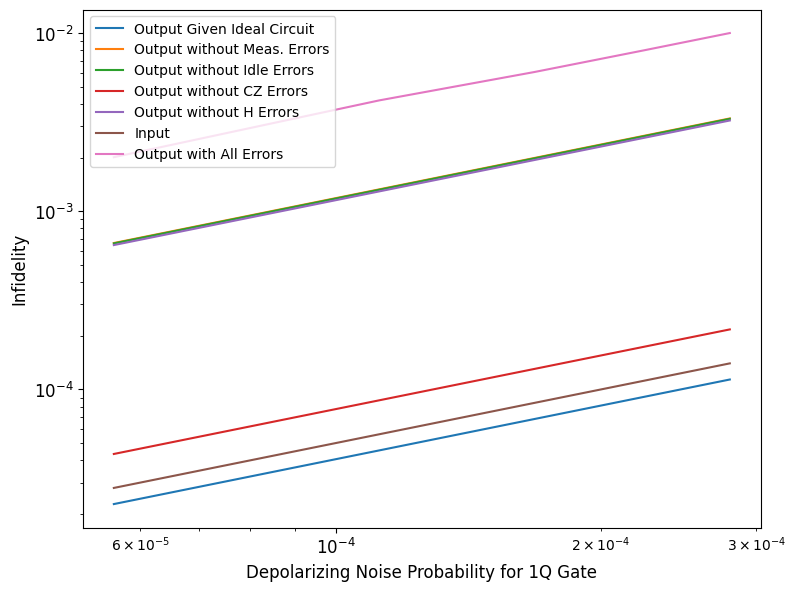

In [32]:
# Plotting both together
plt.figure(figsize=(8,6))

plt.plot(one_qubit_gate_error_prob, plot1_y, label='Output Given Ideal Circuit')
plt.plot(one_qubit_gate_error_prob, plot2_y, label='Output without Meas. Errors')
plt.plot(one_qubit_gate_error_prob, plot3_y, label='Output without Idle Errors')
plt.plot(one_qubit_gate_error_prob, plot4_y, label='Output without CZ Errors')
plt.plot(one_qubit_gate_error_prob, plot5_y, label='Output without H Errors')
plt.plot(one_qubit_gate_error_prob, all_input_infidelity, label='Input')
plt.plot(one_qubit_gate_error_prob, all_infidelity, label='Output with All Errors')

plt.xscale('log')
plt.yscale('log')

plt.legend()
plt.ylabel('Infidelity', fontsize=12)
plt.xlabel('Depolarizing Noise Probability for 1Q Gate', fontsize=12)
#plt.grid(True, which='both', linestyle=':')
plt.tight_layout()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

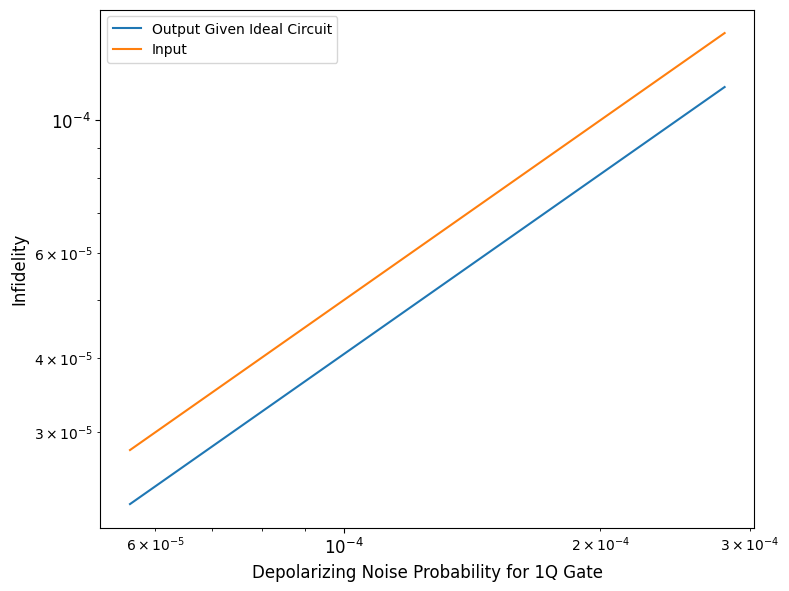

In [33]:
# Plotting both together
plt.figure(figsize=(8,6))

plt.plot(one_qubit_gate_error_prob, plot1_y, label='Output Given Ideal Circuit')
plt.plot(one_qubit_gate_error_prob, all_input_infidelity, label='Input')

plt.xscale('log')
plt.yscale('log')

plt.legend()
plt.ylabel('Infidelity', fontsize=12)
plt.xlabel('Depolarizing Noise Probability for 1Q Gate', fontsize=12)
plt.tight_layout()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# Finding the error rate when the output fidelity is greater than input fidelity

In [51]:
ideal_input = QuantumCircuit(1)
ideal_input.ry(theta, 0)
ideal_input = DensityMatrix(ideal_input)

ideal_output = QuantumCircuit(3)
ideal_output.ry(theta, 2)
ideal_output = DensityMatrix(ideal_output)

In [56]:
input_fidelity_list = []
output_fidelity_list = []
error_rate = 5e-6
better_input = True

while better_input:
    input_circuit = QuantumCircuit(1)
    input_circuit.ry(theta,0)
    
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(error_rate, 1), ['ry'])
    
    input_circuit.save_density_matrix(label='input_dm_post', pershot=True, conditional=True)
    
    backend = AerSimulator(noise_model=nm, method='density_matrix')
    transpiled = transpile(input_circuit, backend, optimization_level=0)
    job = backend.run(transpiled, shots=1)
    input_result = job.result()

    res_density_matrix = input_result.data()['input_dm_post']
    
    input_fidelity_list.append(state_fidelity(ideal_input, res_density_matrix[''][0]))
    
    ###########################################################################################
    
    output_circuit = circuit.copy()
    output_circuit.measure([0, 1], [0, 1]) 
    output_circuit.save_density_matrix(label='output_dm_post', pershot=True, conditional=True)

    backend = AerSimulator(noise_model=nm, method='density_matrix')
    transpiled = transpile(output_circuit, backend, optimization_level=0)
    job = backend.run(transpiled, shots=20)
    output_result = job.result()
    
    res_density_matrix = output_result.data()['output_dm_post']
    output_fidelity_list.append(state_fidelity(ideal_output, res_density_matrix['0x0'][0]))
    
    if (output_fidelity_list[-1] > input_fidelity_list[-1]):
        better_input = False
        print(f"Error Rate = {error_rate}")
    else:
        error_rate /= 2

Error Rate = 3.0517578125e-10
